## Part A

#### 1. What are Statistical Distributions?

A statistical distribution is a mathematical function that describes the relationship between the outcomes of a random variable and their frequency (or probability). Essentially, it tells you which values are common and which are rare. It defines the "shape" of your data.

---
#### 2. What is a Q-Q Plot and why is it used?

A Quantile-Quantile (Q-Q) Plot is a scatterplot created by plotting two sets of quantiles against one another.

   - Why it’s used: Primarily to check if a dataset follows a specific distribution (usually the Normal Distribution).

  - Interpretation: If the data points fall roughly along a straight 45-degree line, the data follows the assumed distribution. Deviations from the line indicate skewness or "heavy tails."
---
#### 3. Difference between Discrete and Continuous Distributions
| Feature	| Discrete Distribution	| Continuous Distribution |
| ------- | --------------------- | ----------------------- |
| Data Type |	Countable values (integers). | Uncountable values (real numbers).|
| Examples |	Number of heads in coin flips. |	Height, weight, or time. |
| Probability |	Probability at a specific point is possible.	|Probability at a specific point is always zero; measured over an interval. |
| Function |	Probability Mass Function (PMF).	| Probability Density Function (PDF). |
---
#### 4. What is Bernoulli Distribution?

The Bernoulli Distribution is the simplest discrete distribution. It represents a single trial with exactly two possible outcomes: Success (1) or Failure (0).

   * Parameter: p (the probability of success).

   * Example: A single toss of a coin (Heads = 1, Tails = 0).
---
#### 5. What is Binomial Distribution?

The Binomial Distribution is the extension of the Bernoulli trial. It models the number of successes in n independent Bernoulli trials.

   * Parameters: n (number of trials) and p (probability of success).

   * Formula: P(X=k)=(kn​)pk(1−p)n−k
---
#### 6. Explain Log-Normal Distribution

A Log-Normal Distribution is a continuous probability distribution of a random variable whose logarithm is normally distributed.

   * Characteristics: It is skewed to the right and only contains positive values.

   * Usage: Commonly used in biology (organ weights) and finance (stock prices), where values cannot be negative but can have extreme positive outliers.
----
#### 7. Explain Power Law Distribution

A Power Law indicates that a relative change in one quantity results in a proportional relative change in another, regardless of the initial size of those quantities.

   * The "80/20 Rule": Also known as the Pareto Principle.

   * Example: 20% of the population owning 80% of the wealth. It is characterized by a "long tail," where a few instances account for a massive portion of the total value.
  ---
#### 8. What is Box-Cox Transform?

The Box-Cox Transform is a statistical technique used to transform non-normal dependent variables into a normal shape.

   * Purpose: Many statistical techniques (like Linear Regression) assume normality. If your data is skewed, Box-Cox applies a power transformation (yλ) to stabilize variance and make the data more "normal-like."
---
#### 9. Explain Poisson Distribution with an Example

The Poisson Distribution models the number of times an event occurs in a fixed interval of time or space, provided these events occur with a known constant mean rate and independently of the time since the last event.

  *  Example: The number of emails received in an hour, or the number of customers arriving at a drive-thru between 12:00 PM and 1:00 PM.
---
#### 10. What is Z-score Probability?

A Z-score (or standard score) tells you how many standard deviations a data point is from the mean.

   * Formula: z=x−μ/σ​

   * Probability: By looking up a Z-score in a Standard Normal Table, you can find the probability (area under the curve) that a value will fall below, above, or between specific points in a normal distribution.
---
#### 11. Differentiate PDF and CDF
Probability Density Function (PDF)

The PDF represents the probability of a continuous random variable falling within a particular range of values. The area under the PDF curve between two points represents the probability of the variable falling in that range.
Cumulative Distribution Function (CDF)

The CDF calculates the cumulative probability for a given value. It tells you the probability that the random variable will take a value less than or equal to x.

   * The CDF always ranges from 0 to 1.

   * The derivative of the CDF is the PDF.
   ---

## Part B

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


Saving dataset.csv to dataset.csv


In [2]:
data = pd.read_csv('dataset.csv')

In [3]:
data['transaction_date'] = pd.to_datetime(data['transaction_date'])

#### 1. Binomial Distribution

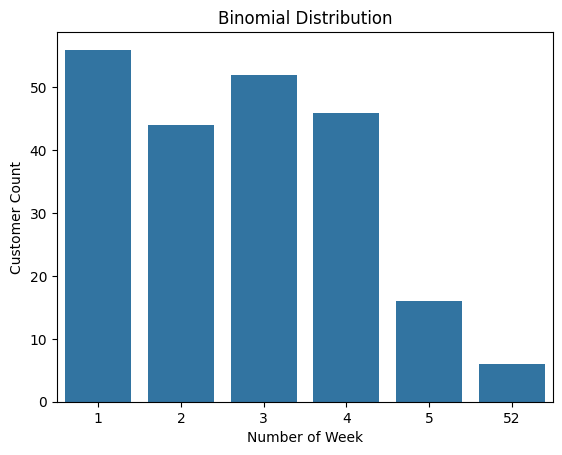

In [4]:
sns.barplot((data['transaction_date'].dt.isocalendar().week).value_counts())
plt.title('Binomial Distribution')
plt.xlabel('Number of Week')
plt.ylabel('Customer Count')
plt.show()

#### 2. Poisson Distribution

In [5]:
lambda_value = (data['transaction_date'].dt.isocalendar().day).mean()

days = np.sort((data['transaction_date'].dt.isocalendar().day).value_counts().index)

prob = stats.poisson.pmf(days,lambda_value)

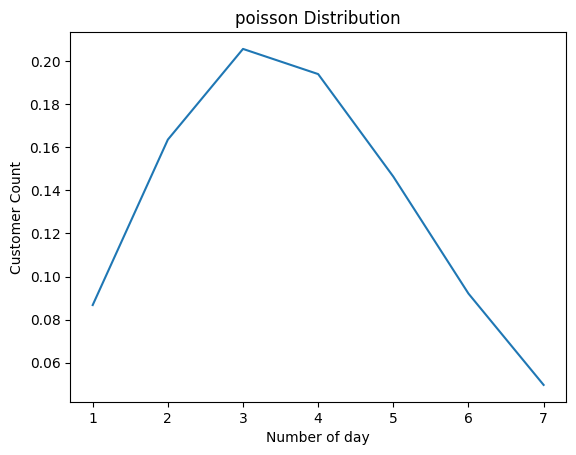

In [6]:
plt.plot(days,prob)
plt.title('poisson Distribution')
plt.xlabel('Number of day')
plt.ylabel('Customer Count')
plt.show()

#### 3. Log-Normal or Power Law Distribution

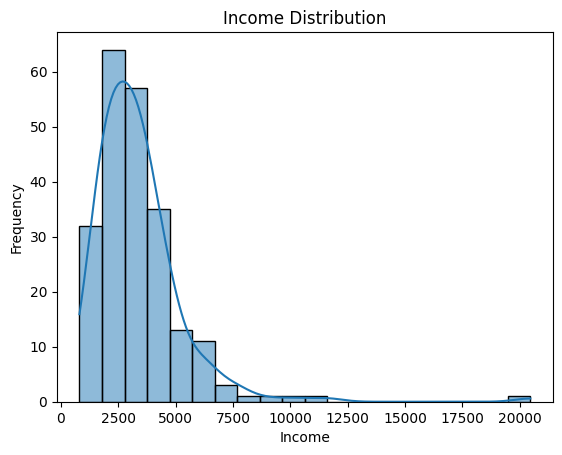

In [7]:
sns.histplot(data['transaction_amount'],kde=True,bins=20)
plt.title('Income Distribution')
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

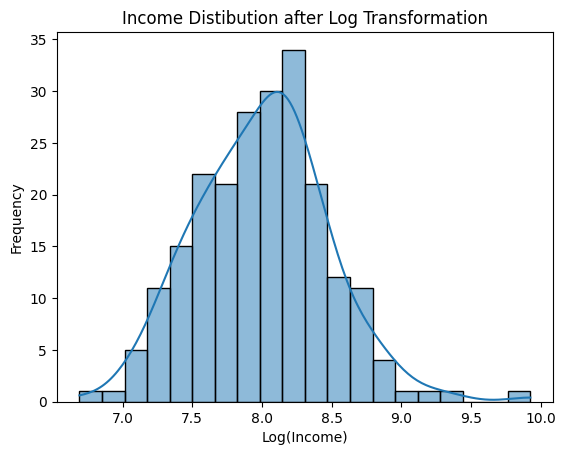

In [8]:
sns.histplot(np.log(data['transaction_amount']),kde=True,bins=20)
plt.title('Income Distibution after Log Transformation')
plt.xlabel("Log(Income)")
plt.ylabel("Frequency")
plt.show()

#### 4. Q-Q Plot

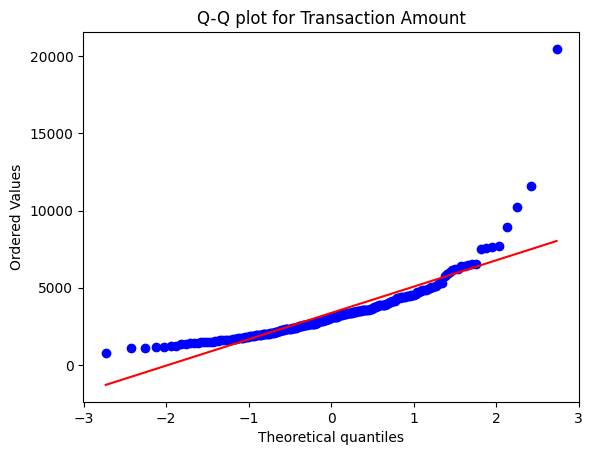

In [9]:
stats.probplot(data['transaction_amount'], dist="norm", plot=plt)
plt.title('Q-Q plot for Transaction Amount')
plt.show()

#### 5. Box-Cox Tranformation

In [10]:
income_boxcox,lambda_valuestats = stats.boxcox(data['transaction_amount'])

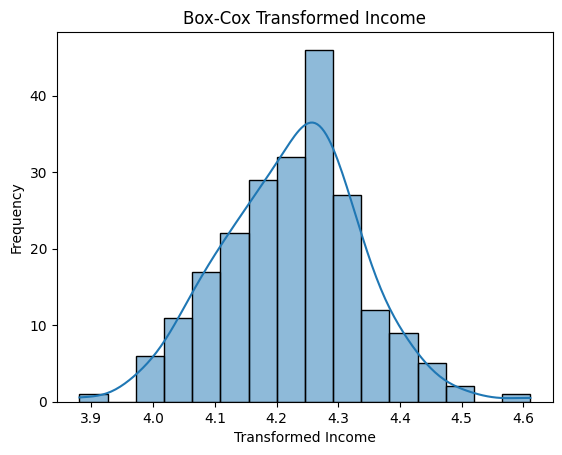

In [14]:
sns.histplot(income_boxcox,kde=True)
plt.title("Box-Cox Transformed Income")
plt.xlabel("Transformed Income")
plt.ylabel("Frequency")
plt.show()

#### 6. Z Score

In [22]:
sample_mean = data['transaction_amount'].mean()
std = data['transaction_amount'].std()
n = len(data['transaction_amount'])
population_mean = 5000
alpha = 0.05

z_score = (sample_mean - population_mean) / (std / np.sqrt(n))

critical_z = stats.norm.ppf(1- alpha)


z_score,critical_z

(np.float64(-12.211335605427518), np.float64(1.6448536269514722))

In [23]:
if z_score > critical_z:
    print("The z-score falls outside the decision boundary, so we reject the null hypothesis. The average screen time has significantly increased.")
else:
    print("The z-score falls within the decision boundary, so we fail to reject the null hypothesis. There is no significant increase in screen time.")

The z-score falls within the decision boundary, so we fail to reject the null hypothesis. There is no significant increase in screen time.


#### 7. PDF and CDF

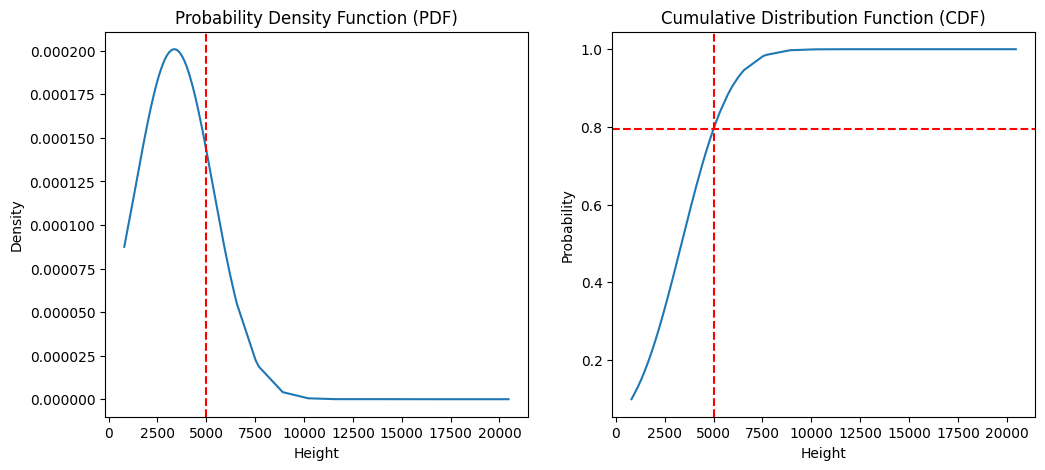

In [46]:
x=5000

x_values = np.sort(data['transaction_amount'])
mean = data['transaction_amount'].mean()
std = data['transaction_amount'].std()
pdf_values = stats.norm.pdf(x_values,mean,std)
cdf_values = stats.norm.cdf(x_values,mean,std)
cdf_value = stats.norm.cdf(x,mean,std)

plt.figure(figsize=(12,5))

# PDF Plot
plt.subplot(1,2,1)
plt.plot(x_values, pdf_values)
plt.axvline(x, color="red", linestyle="--")
plt.title("Probability Density Function (PDF)")
plt.xlabel("Height")
plt.ylabel("Density")

# CDF Plot
plt.subplot(1,2,2)
plt.plot(x_values, cdf_values)
plt.axvline(x, color="red", linestyle="--")
plt.axhline(cdf_value, color="red", linestyle="--")
plt.title("Cumulative Distribution Function (CDF)")
plt.xlabel("Height")
plt.ylabel("Probability")

plt.show()

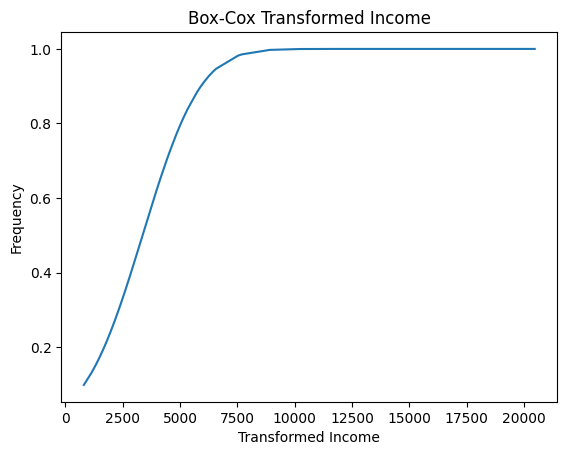

In [38]:
mean = data['transaction_amount'].mean()
std = data['transaction_amount'].std()
norm_val = stats.norm.cdf(np.sort(data['transaction_amount']),mean,std)

plt.plot(np.sort(data['transaction_amount']),norm_val)
plt.title("Cumulative Distribution Function")
plt.xlabel("Income")
plt.ylabel("Cumulative Probability")
plt.show()

#### Insights or Next Steps
*   The `transaction_amount` data inherently follows a Log-Normal distribution due to its positive values and significant right-skewness, which is confirmed by the effectiveness of the logarithmic transformation in achieving approximate normality.
*   For any subsequent statistical modeling or analysis that assumes normality (e.g., parametric tests, linear regression), it is highly recommended to use either the log-transformed or Box-Cox transformed `transaction_amount` data to ensure the validity of results.